# Project Module 3 - Robustness and Security Testing

**Course:** CSCE 4930 - Responsible & Ethical AI  
**Instructor:** Dr. Alia El Bolock  

**Team:** Adham Ali – 900223243 | Omar Saqr – 900223343 | Ebram Thabet – 900214496 | Saif Abd Elfattah – 900225535  

---

## Part 1: Baseline Model and Clean Evaluation (10%)

| Requirement | Where |
|-------------|--------|
| Reuse Module 1 data loading and preprocessing | Section 1 |
| Train baseline model | Section 2 |
| Accuracy, Precision, Recall, F1 on clean test + visible outputs | Section 3 (table, bar chart, confusion matrix, CSV) |
| Written answers (2 questions) | Section 4 |
| Part 2: at least 3 perturbations, results table, figure, 3 answers | Sections 5–6 |

Chosen model: Decision Tree - `max_depth=5`, `criterion="gini"`, `min_samples_leaf=10`, `random_state=42` - same as Module 2.

Target: `credit_risk` → 1 = Good, 0 = Bad. Precision, Recall, and F1 use `pos_label=1` (Good) unless stated otherwise.

`sex`, `age_group`, and `foreign_worker` are in `X` and go into the model - same as Module 2. `A_test` keeps them as a separate slice for subgroup checks in later parts.


---
## Setup


In [2]:
!pip install pandas numpy scikit-learn matplotlib requests --quiet

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"  RANDOM_STATE = {RANDOM_STATE} (split + tree)")


Libraries loaded.
  pandas 2.3.3 | numpy 2.0.2 | scikit-learn 1.6.1
  RANDOM_STATE = 42 (split + tree)


---
## 1. Data Loading (Module 1 / Module 2 Pipeline)

- Source: the same CSV file used in Module 2, saved at `data/german_credit_data.csv`.
- Target: `credit_risk` encoded as 0 = Bad, 1 = Good.
- Extra columns (same as Module 2): `sex` from `personal_status_sex`; `age_group` from `age` (cutoff: 25).
- Split: 80% train / 20% test, stratified on `y`, seed `RANDOM_STATE`.
- Preprocessing: numeric columns - fill missing with median, then scale with `StandardScaler`; categorical columns - fill missing with most frequent value, then one-hot encode.

`A_test` saves `sex`, `age_group`, and `foreign_worker` from the test set - the same three groups checked in Module 2 Part 6. Used for subgroup analysis in later parts of this notebook.


In [3]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "german_credit_data.csv"
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

if not data_path.exists():
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, "wb") as f:
        f.write(r.content)
    print("Dataset downloaded.")
else:
    print("Dataset already cached.")

df = pd.read_csv(data_path)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

target_col = "credit_risk"
if df[target_col].dtype == "object":
    cleaned = df[target_col].astype(str).str.strip().str.lower()
    if set(cleaned.unique()).issubset({"good", "bad"}):
        df[target_col] = cleaned.map({"good": 1, "bad": 0})
    else:
        df[target_col] = cleaned.astype(int)
else:
    df[target_col] = df[target_col].astype(int)


df["sex"] = df["personal_status_sex"].apply(
    lambda x: "female" if "female" in str(x).lower() else "male"
)
df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


cat_encoder = preprocessor.named_transformers_["cat"]["encoder"]
cat_feat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feat_names


A_test = X_test[["sex", "age_group", "foreign_worker"]].copy()

print("Dataset shape (with derived sex, age_group):", df.shape)
print("Train:", X_train.shape[0], "| Test (clean):", X_test.shape[0])
print("Numeric / categorical raw columns:", len(numeric_features), "/", len(categorical_features))
print("Processed feature count:", X_train_processed.shape[1])
print("\nTarget distribution (train):")
print(y_train.value_counts())
print("\nTarget distribution (test - clean hold-out):")
print(y_test.value_counts())


Dataset already cached.
Dataset shape (with derived sex, age_group): (1000, 23)
Train: 800 | Test (clean): 200
Numeric / categorical raw columns: 7 / 15
Processed feature count: 65

Target distribution (train):
credit_risk
1    560
0    240
Name: count, dtype: int64

Target distribution (test - clean hold-out):
credit_risk
1    140
0     60
Name: count, dtype: int64


---
## 2. Baseline Model Training

We use a Decision Tree - same as Module 2 - trained only on the training data.

Hyperparameters: `max_depth=5`, `criterion="gini"`, `min_samples_leaf=10`, `random_state=42`.

Train accuracy is checked as a quick sanity check. The actual graded metrics are in Section 3.


In [4]:
baseline_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)
baseline_model.fit(X_train_processed, y_train)

y_pred_train = baseline_model.predict(X_train_processed)
y_pred_clean = baseline_model.predict(X_test_processed)

train_acc = accuracy_score(y_train, y_pred_train)
acc = accuracy_score(y_test, y_pred_clean)

prec = precision_score(y_test, y_pred_clean, pos_label=1, zero_division=0)
rec = recall_score(y_test, y_pred_clean, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred_clean, pos_label=1, zero_division=0)

print("Training complete (baseline Decision Tree).")
print(f"Train accuracy (sanity check, in-sample): {train_acc:.4f}")


Training complete (baseline Decision Tree).
Train accuracy (sanity check, in-sample): 0.7638


---
## 3. Clean Test Performance

The clean test set is the 200-sample hold-out from Section 1, processed the same way as training, with no noise or changes added.

Metrics reported: Accuracy; Precision, Recall, and F1 for the Good class (label 1); F1 (macro) for both classes. Outputs: summary table, `module3_part1_baseline_metrics.csv`, bar chart (`module3_part1_metrics_bar.png`), confusion matrix (`module3_part1_confusion_matrix_clean.png`), and a `BASELINE_PART1` dict for later parts.


CLEAN TEST PERFORMANCE - Baseline Decision Tree
(Test set: untouched / clean; positive class for P/R/F1 = Good = 1)
Accuracy     : 0.7100
Precision    : 0.7253   [Good class]
Recall       : 0.9429   [Good class]
F1-score     : 0.8199   [Good class]
F1 (macro)   : 0.5381   [unweighted mean F1 over Bad & Good]

Per-class breakdown (clean test):
              precision    recall  f1-score   support

     Bad (0)       0.56      0.17      0.26        60
    Good (1)       0.73      0.94      0.82       140

    accuracy                           0.71       200
   macro avg       0.64      0.55      0.54       200
weighted avg       0.67      0.71      0.65       200


Summary table (copy for report if needed):
          Metric    Value
        Accuracy 0.710000
Precision (Good) 0.725275
   Recall (Good) 0.942857
       F1 (Good) 0.819876
      F1 (macro) 0.538143

Saved: D:\Spring 2026\Ethics\Project\Milestone 3\module3_part1_baseline_metrics.csv


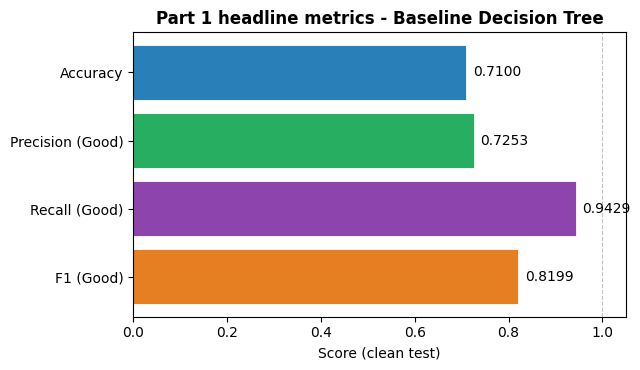

Figure saved: module3_part1_metrics_bar.png


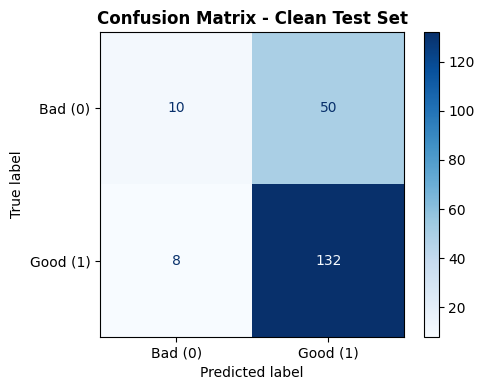

Figure saved: module3_part1_confusion_matrix_clean.png

Feature importance (Part 1 tree - same spec as Module 2):
  Top feature: 'status_no checking account' | importance=0.3662 | ~36.6% of total tree importance
  `amount` rank 3 | importance=0.1103

BASELINE_PART1 (dict - use in later parts for comparisons):
  model: DecisionTreeClassifier
  hyperparameters: {'max_depth': 5, 'criterion': 'gini', 'min_samples_leaf': 10, 'random_state': 42}
  n_train: 800
  n_test_clean: 200
  random_state_split: 42
  clean_test_accuracy: 0.71
  clean_test_precision_good: 0.7252747252747253
  clean_test_recall_good: 0.9428571428571428
  clean_test_f1_good: 0.8198757763975155
  clean_test_f1_macro: 0.538143016403886
  train_accuracy_in_sample: 0.76375


In [5]:
f1_macro = f1_score(y_test, y_pred_clean, average="macro", zero_division=0)

print("=" * 60)
print("CLEAN TEST PERFORMANCE - Baseline Decision Tree")
print("(Test set: untouched / clean; positive class for P/R/F1 = Good = 1)")
print("=" * 60)
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}   [Good class]")
print(f"Recall       : {rec:.4f}   [Good class]")
print(f"F1-score     : {f1:.4f}   [Good class]")
print(f"F1 (macro)   : {f1_macro:.4f}   [unweighted mean F1 over Bad & Good]")
print()
print("Per-class breakdown (clean test):")
print(classification_report(y_test, y_pred_clean, target_names=["Bad (0)", "Good (1)"]))

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Good)", "Recall (Good)", "F1 (Good)", "F1 (macro)"],
    "Value": [acc, prec, rec, f1, f1_macro],
})
print("\nSummary table (copy for report if needed):")
print(summary.to_string(index=False))

summary_path = Path("module3_part1_baseline_metrics.csv")
summary.to_csv(summary_path, index=False)
print(f"\nSaved: {summary_path.resolve()}")


fig_bar, ax_bar = plt.subplots(figsize=(6.5, 3.8))
headline = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Good)", "Recall (Good)", "F1 (Good)"],
    "Value": [acc, prec, rec, f1],
})
colors_bar = ["#2980b9", "#27ae60", "#8e44ad", "#e67e22"]
ax_bar.barh(headline["Metric"], headline["Value"], color=colors_bar, edgecolor="white", linewidth=0.6)
ax_bar.set_xlim(0, 1.05)
ax_bar.axvline(1.0, color="#bdc3c7", linestyle="--", linewidth=0.8)
ax_bar.set_xlabel("Score (clean test)")
ax_bar.set_title("Part 1 headline metrics - Baseline Decision Tree", fontsize=12, fontweight="bold")
ax_bar.invert_yaxis()
for i, v in enumerate(headline["Value"]):
    ax_bar.text(v + 0.015, i, f"{v:.4f}", va="center", fontsize=10)
plt.tight_layout()
bar_path = Path("module3_part1_metrics_bar.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {bar_path}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_clean,
    display_labels=["Bad (0)", "Good (1)"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix - Clean Test Set", fontsize=12, fontweight="bold")
plt.tight_layout()
cm_path = Path("module3_part1_confusion_matrix_clean.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {cm_path}")

feat_imp = pd.Series(
    baseline_model.feature_importances_,
    index=all_feature_names,
).sort_values(ascending=False)

TREE_IMPORTANCE = {
    "top_feature": str(feat_imp.index[0]),
    "top_importance": float(feat_imp.iloc[0]),
    "top_share_pct": float(100.0 * feat_imp.iloc[0] / feat_imp.sum()),
    "amount_importance": float(feat_imp["amount"]),
    "amount_rank": int(feat_imp.index.get_loc("amount")) + 1,
}

BASELINE_PART1 = {
    "model": "DecisionTreeClassifier",
    "hyperparameters": {
        "max_depth": 5,
        "criterion": "gini",
        "min_samples_leaf": 10,
        "random_state": RANDOM_STATE,
    },
    "n_train": int(X_train.shape[0]),
    "n_test_clean": int(X_test.shape[0]),
    "random_state_split": RANDOM_STATE,
    "clean_test_accuracy": float(acc),
    "clean_test_precision_good": float(prec),
    "clean_test_recall_good": float(rec),
    "clean_test_f1_good": float(f1),
    "clean_test_f1_macro": float(f1_macro),
    "train_accuracy_in_sample": float(train_acc),
}
print("\nFeature importance (Part 1 tree - same spec as Module 2):")
print(
    f"  Top feature: {TREE_IMPORTANCE['top_feature']!r} | "
    f"importance={TREE_IMPORTANCE['top_importance']:.4f} | "
    f"~{TREE_IMPORTANCE['top_share_pct']:.1f}% of total tree importance"
)
print(
    f"  `amount` rank {TREE_IMPORTANCE['amount_rank']} | "
    f"importance={TREE_IMPORTANCE['amount_importance']:.4f}"
)

print("\nBASELINE_PART1 (dict - use in later parts for comparisons):")
for k, v in BASELINE_PART1.items():
    print(f"  {k}: {v}")


In [6]:
from IPython.display import display, Markdown

hp = BASELINE_PART1["hyperparameters"]
n_test = BASELINE_PART1["n_test_clean"]
n_bad = int((y_test == 0).sum())
n_good = int((y_test == 1).sum())

prec_bad = precision_score(y_test, y_pred_clean, pos_label=0, zero_division=0)
rec_bad = recall_score(y_test, y_pred_clean, pos_label=0, zero_division=0)
f1_bad = f1_score(y_test, y_pred_clean, pos_label=0, zero_division=0)

acc = BASELINE_PART1["clean_test_accuracy"]
prec = BASELINE_PART1["clean_test_precision_good"]
rec = BASELINE_PART1["clean_test_recall_good"]
f1g = BASELINE_PART1["clean_test_f1_good"]
f1m = BASELINE_PART1["clean_test_f1_macro"]

q1 = f"""### 1. What is the baseline performance of your model?

Model: Decision Tree, `max_depth={hp["max_depth"]}`, `criterion="{hp["criterion"]}"`, `min_samples_leaf={hp["min_samples_leaf"]}`, `random_state={hp["random_state"]}` - same as Module 2.

Evaluated on the clean hold-out test set (n = {n_test}), with no changes applied.

| Metric | Value |
| :--- | :--- |
| Accuracy | {acc:.4f} |
| Precision (Good) | {prec:.4f} |
| Recall (Good) | {rec:.4f} |
| F1-score (Good) | {f1g:.4f} |
| F1 (macro) | {f1m:.4f} |

Out of {n_bad} truly Bad applicants - precision {prec_bad:.2f}, recall {rec_bad:.2f}, F1 {f1_bad:.2f}. Out of {n_good} truly Good - precision {prec:.2f}, recall {rec:.2f}, F1 {f1g:.2f}.

The accuracy of {acc:.2f} looks okay, but the model is much better at spotting Good applicants than Bad ones. It only catches {rec_bad:.2f} of truly Bad applicants - meaning most high-risk people are wrongly approved. This matches Module 2: high Good recall ({rec:.2f}) pushes the F1 score up, but Bad detection stays weak. In a real credit system, missing so many Bad applicants is a serious problem.
"""

q2 = """### 2. Why is performance on clean data not sufficient to trust a model?

A good score on clean test data only tells us the model works on ideal, controlled data. It does not mean the model is safe or fair in the real world.

1. Real data has noise, missing fields, typos, and people who try to game the system. Clean test data has none of that. Part 2 tests some of these.

2. The world changes. A model trained on old data may not work well on new applicants with different habits or economic conditions.

3. A good accuracy score can hide the fact that the model treats some groups - like young applicants or foreign workers - much worse. This matters for fairness and regulation.

4. Banks and regulators need explanations, monitoring over time, and ways for applicants to appeal decisions - not just a single number.

Clean metrics are a starting point, not a final answer. They give us a reference for the stress tests and fairness checks that follow.
"""

answers_part1_md = "---\n## 4. Part 1 - Analysis Answers\n\n" + q1 + "\n\n---\n\n" + q2 + "\n\n---\n"
display(Markdown(answers_part1_md))


---
## 4. Part 1 - Analysis Answers

### 1. What is the baseline performance of your model?

Model: Decision Tree, `max_depth=5`, `criterion="gini"`, `min_samples_leaf=10`, `random_state=42` - same as Module 2.

Evaluated on the clean hold-out test set (n = 200), with no changes applied.

| Metric | Value |
| :--- | :--- |
| Accuracy | 0.7100 |
| Precision (Good) | 0.7253 |
| Recall (Good) | 0.9429 |
| F1-score (Good) | 0.8199 |
| F1 (macro) | 0.5381 |

Out of 60 truly Bad applicants - precision 0.56, recall 0.17, F1 0.26. Out of 140 truly Good - precision 0.73, recall 0.94, F1 0.82.

The accuracy of 0.71 looks okay, but the model is much better at spotting Good applicants than Bad ones. It only catches 0.17 of truly Bad applicants - meaning most high-risk people are wrongly approved. This matches Module 2: high Good recall (0.94) pushes the F1 score up, but Bad detection stays weak. In a real credit system, missing so many Bad applicants is a serious problem.


---

### 2. Why is performance on clean data not sufficient to trust a model?

A good score on clean test data only tells us the model works on ideal, controlled data. It does not mean the model is safe or fair in the real world.

1. Real data has noise, missing fields, typos, and people who try to game the system. Clean test data has none of that. Part 2 tests some of these.

2. The world changes. A model trained on old data may not work well on new applicants with different habits or economic conditions.

3. A good accuracy score can hide the fact that the model treats some groups - like young applicants or foreign workers - much worse. This matters for fairness and regulation.

4. Banks and regulators need explanations, monitoring over time, and ways for applicants to appeal decisions - not just a single number.

Clean metrics are a starting point, not a final answer. They give us a reference for the stress tests and fairness checks that follow.


---


---

## Part 2: Robustness Stress Testing (30%)

We apply at least three changes to the test data, run the same model from Part 1 on each changed version (no retraining), and compare the results to the clean baseline.

| Requirement | How |
|-------------|-----|
| At least 3 perturbations | Four scenarios: noise, rounding, missing values, and a swapped categorical field. |
| Scenarios | Gaussian noise on numbers; reduced precision; missing values filled with median; wrong `status` category. |
| Performance vs baseline | Table with accuracy, error rate, precision, recall, F1, delta vs baseline, and flip rate. |
| Results table | Printed below and saved to `module3_part2_robustness_results.csv`. |
| At least one visualization | Accuracy bar chart; accuracy vs error rate panel; flip-rate chart. |
| Three written answers | Section 6. |

We only change test data - not training data. The model and preprocessor stay the same. Random steps use `PERTURB_SEED` for reproducibility.


---
## 5. Perturbation Protocol and Metrics

1. Baseline: predictions on the clean `X_test` from Part 1.
2. Each scenario: apply the change to `X_test` → preprocess → predict → compare to `y_test` and to the clean predictions.
3. Metrics: Accuracy; Error rate (= 1 − Accuracy); Precision, Recall, F1 for Good (label 1); F1 macro; Flip rate (fraction of predictions that changed from the clean run).

Scenario D swaps two `status` category values. The `status` field is the most important feature in the tree - it is the root split and holds the largest share of Gini importance (see the `TREE_IMPORTANCE` output above). Changing it puts more stress on the model than changing a numeric field like `amount` would.

We only change what the model sees at prediction time. We never retrain.


In [7]:
PERTURB_SEED = 12345
PART2_NOISE_SCALE = 0.22
PART2_MISSING_FRAC = 0.15


def _predict_from_raw(X_df: pd.DataFrame) -> np.ndarray:
    X_proc = preprocessor.transform(X_df)
    return baseline_model.predict(X_proc)


def _metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_good": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_good": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_good": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def perturb_gaussian_noise(X: pd.DataFrame, numeric_cols, train_ref: pd.DataFrame, rng, rel_scale) -> pd.DataFrame:
    out = X.copy()
    for c in numeric_cols:
        sigma = float(train_ref[c].std(ddof=0))
        if sigma == 0 or np.isnan(sigma):
            continue
        out[c] = out[c].astype(float) + rng.normal(0.0, rel_scale * sigma, size=len(out))
    return out


def perturb_coarse_numeric(X: pd.DataFrame, numeric_cols) -> pd.DataFrame:
    out = X.copy()
    for c in numeric_cols:
        v = out[c].astype(float)
        if c in ("amount", "duration"):
            out[c] = np.round(v / 100.0) * 100.0
        else:
            out[c] = np.round(v, 0)
    return out


def perturb_random_missing(X: pd.DataFrame, numeric_cols, rng, missing_frac) -> pd.DataFrame:
    out = X.copy()
    mat = out[numeric_cols].to_numpy(dtype=float)
    mask = rng.random(mat.shape) < missing_frac
    mat = mat.astype(float)
    mat[mask] = np.nan
    for j, c in enumerate(numeric_cols):
        out[c] = mat[:, j]
    return out


def perturb_swap_checking_status(X: pd.DataFrame) -> pd.DataFrame:
    out = X.copy()
    if "status" not in out.columns:
        raise ValueError("Expected column 'status' (checking account).")
    col = out["status"].astype(str)
    mapping = {
        "no checking account": "... < 100 DM",
        "... < 100 DM": "no checking account",
    }
    mapped = col.replace(mapping)
    n_swapped = int((col != mapped).sum())
    print(f"Status swap: {n_swapped} rows changed (0 means labels did not match mapping keys exactly).")
    out["status"] = mapped
    return out


rows_part2 = []
yt = y_test.values


m0 = _metrics(yt, y_pred_clean)
rows_part2.append({
    "scenario": "Baseline (clean test)",
    "accuracy": m0["accuracy"],
    "precision_good": m0["precision_good"],
    "recall_good": m0["recall_good"],
    "f1_good": m0["f1_good"],
    "f1_macro": m0["f1_macro"],
    "prediction_flip_rate": 0.0,
})

scenarios = [
    (f"A) Gaussian noise on numerics ({PART2_NOISE_SCALE}× train σ)", lambda: perturb_gaussian_noise(
        X_test, numeric_features, X_train, np.random.default_rng(PERTURB_SEED), PART2_NOISE_SCALE)),
    ("B) Coarsen numerics (amount/duration → nearest 100)", lambda: perturb_coarse_numeric(X_test, numeric_features)),
    (f"C) {int(PART2_MISSING_FRAC * 100)}% random missing numerics → median impute", lambda: perturb_random_missing(
        X_test, numeric_features, np.random.default_rng(PERTURB_SEED + 1), PART2_MISSING_FRAC)),
    ("D) Mis-reported `status` (swap 'no checking account' ↔ '... < 100 DM')", lambda: perturb_swap_checking_status(X_test)),
]

for label, factory in scenarios:
    X_pert = factory()
    y_hat = _predict_from_raw(X_pert)
    m = _metrics(yt, y_hat)
    flip = float(np.mean(y_pred_clean != y_hat))
    rows_part2.append({
        "scenario": label,
        "accuracy": m["accuracy"],
        "precision_good": m["precision_good"],
        "recall_good": m["recall_good"],
        "f1_good": m["f1_good"],
        "f1_macro": m["f1_macro"],
        "prediction_flip_rate": flip,
    })

results_part2 = pd.DataFrame(rows_part2)
base = results_part2.iloc[0]
base_acc = float(base["accuracy"])
results_part2["error_rate"] = 1.0 - results_part2["accuracy"].astype(float)
base_er = float(results_part2.loc[0, "error_rate"])
results_part2["delta_accuracy"] = results_part2["accuracy"] - base_acc
results_part2["delta_error_rate"] = results_part2["error_rate"] - base_er
results_part2["delta_precision_good"] = results_part2["precision_good"] - base["precision_good"]
results_part2["delta_recall_good"] = results_part2["recall_good"] - base["recall_good"]
results_part2["delta_f1_good"] = results_part2["f1_good"] - base["f1_good"]
results_part2["delta_f1_macro"] = results_part2["f1_macro"] - base["f1_macro"]

show_cols = [
    "scenario",
    "accuracy",
    "error_rate",
    "delta_accuracy",
    "delta_error_rate",
    "precision_good",
    "recall_good",
    "f1_good",
    "f1_macro",
    "delta_precision_good",
    "delta_recall_good",
    "delta_f1_good",
    "delta_f1_macro",
    "prediction_flip_rate",
]

print("Part 2 - robustness comparison (test set)")
print(results_part2[show_cols].to_string(index=False))

csv_p2 = Path("module3_part2_robustness_results.csv")
results_part2.to_csv(csv_p2, index=False)
print(f"\nSaved: {csv_p2.resolve()}")

print("\n--- Assignment checklist ---")
print(f"  • Perturbations (≥3): {len(scenarios)} stresses + baseline row in table/CSV.")
print("  • Each scenario: metrics + Δ vs baseline (accuracy, error rate, F1, flips).")
print("  • Figures: accuracy bars; dual metric panel; flip-rate bar chart.")


Status swap: 120 rows changed (0 means labels did not match mapping keys exactly).
Part 2 - robustness comparison (test set)
                                                              scenario  accuracy  error_rate  delta_accuracy  delta_error_rate  precision_good  recall_good  f1_good  f1_macro  delta_precision_good  delta_recall_good  delta_f1_good  delta_f1_macro  prediction_flip_rate
                                                 Baseline (clean test)     0.710       0.290           0.000             0.000        0.725275     0.942857 0.819876  0.538143              0.000000           0.000000       0.000000        0.000000                 0.000
                         A) Gaussian noise on numerics (0.22× train σ)     0.710       0.290           0.000             0.000        0.722826     0.950000 0.820988  0.528915             -0.002449           0.007143       0.001112       -0.009228                 0.040
                   B) Coarsen numerics (amount/duration → nearest 10

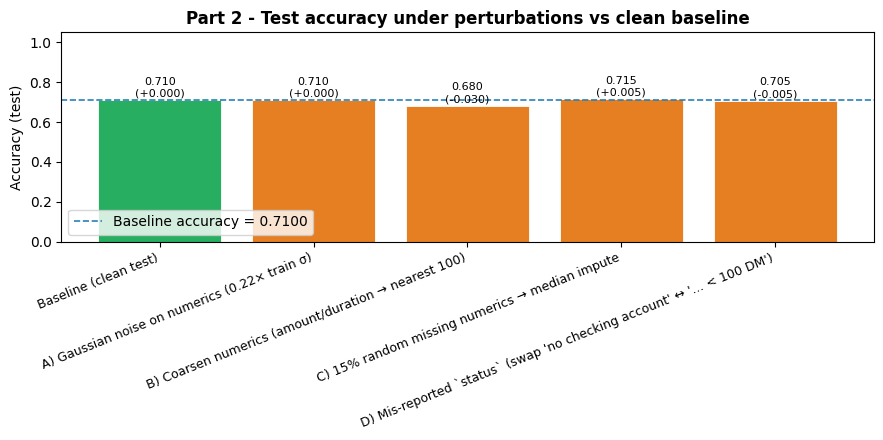

Figure saved: module3_part2_accuracy_under_stress.png


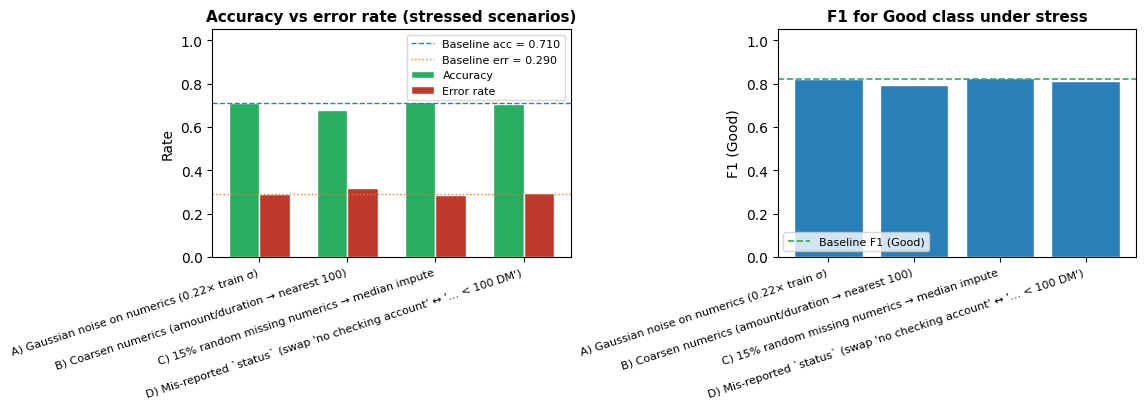

Figure saved: module3_part2_metrics_accuracy_error_f1.png


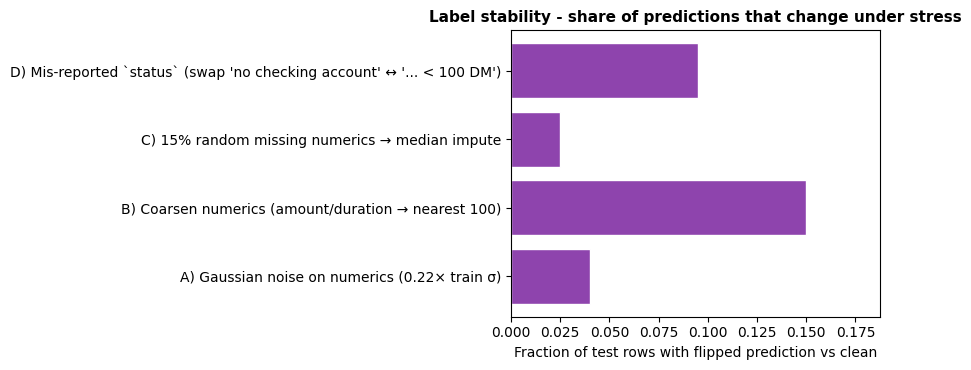

Figure saved: module3_part2_prediction_flip_rates.png


In [8]:

fig, ax = plt.subplots(figsize=(9, 4.5))
scen = results_part2["scenario"].tolist()
x = np.arange(len(scen))
bars = ax.bar(x, results_part2["accuracy"], color=["#27ae60"] + ["#e67e22"] * (len(scen) - 1), edgecolor="white", linewidth=0.6)
ax.axhline(base_acc, color="#2980b9", linestyle="--", linewidth=1.2, label=f"Baseline accuracy = {base_acc:.4f}")
ax.set_xticks(x)
ax.set_xticklabels(scen, rotation=22, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (test)")
ax.set_ylim(0, 1.05)
ax.set_title("Part 2 - Test accuracy under perturbations vs clean baseline", fontsize=12, fontweight="bold")
for i, (v, d) in enumerate(zip(results_part2["accuracy"], results_part2["delta_accuracy"])):
    ax.text(i, v + 0.02, f"{v:.3f}\n({d:+.3f})", ha="center", fontsize=8)
ax.legend(loc="lower left")
plt.tight_layout()
fig_path = Path("module3_part2_accuracy_under_stress.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")


stress = results_part2.iloc[1:].reset_index(drop=True)
fig_m, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11.5, 4.2))
xi = np.arange(len(stress))
w = 0.35
ax_l.bar(xi - w / 2, stress["accuracy"], width=w, label="Accuracy", color="#27ae60", edgecolor="white")
ax_l.bar(xi + w / 2, stress["error_rate"], width=w, label="Error rate", color="#c0392b", edgecolor="white")
ax_l.axhline(base_acc, color="#2980b9", linestyle="--", linewidth=1.0, label=f"Baseline acc = {base_acc:.3f}")
ax_l.axhline(base_er, color="#e67e22", linestyle=":", linewidth=1.0, label=f"Baseline err = {base_er:.3f}")
ax_l.set_xticks(xi)
ax_l.set_xticklabels(stress["scenario"], rotation=18, ha="right", fontsize=8)
ax_l.set_ylim(0, 1.05)
ax_l.set_ylabel("Rate")
ax_l.set_title("Accuracy vs error rate (stressed scenarios)", fontsize=11, fontweight="bold")
ax_l.legend(loc="upper right", fontsize=8)

ax_r.bar(xi, stress["f1_good"], color="#2980b9", edgecolor="white")
ax_r.axhline(float(results_part2.loc[0, "f1_good"]), color="#27ae60", linestyle="--", linewidth=1.2, label="Baseline F1 (Good)")
ax_r.set_xticks(xi)
ax_r.set_xticklabels(stress["scenario"], rotation=18, ha="right", fontsize=8)
ax_r.set_ylabel("F1 (Good)")
ax_r.set_ylim(0, 1.05)
ax_r.set_title("F1 for Good class under stress", fontsize=11, fontweight="bold")
ax_r.legend(loc="lower left", fontsize=8)
plt.tight_layout()
fig_m_path = Path("module3_part2_metrics_accuracy_error_f1.png")
plt.savefig(fig_m_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_m_path}")


fig2, ax2 = plt.subplots(figsize=(9, 3.8))
sub = results_part2.iloc[1:]
ax2.barh(sub["scenario"], sub["prediction_flip_rate"], color="#8e44ad", edgecolor="white")
ax2.set_xlabel("Fraction of test rows with flipped prediction vs clean")
ax2.set_title("Label stability - share of predictions that change under stress", fontsize=11, fontweight="bold")
ax2.set_xlim(0, max(0.15, sub["prediction_flip_rate"].max() * 1.25))
plt.tight_layout()
fig2_path = Path("module3_part2_prediction_flip_rates.png")
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig2_path}")


---
## 6. Part 2 - Analysis Answers

The next cell shows the three written answers using `IPython.display.Markdown`. Run it after the evaluation cells and plots above.


In [9]:
from IPython.display import display, Markdown

sub = results_part2.iloc[1:].copy()
worst_idx = sub["accuracy"].idxmin()
worst_row = results_part2.loc[worst_idx]
best_flip = sub.loc[sub["prediction_flip_rate"].idxmax()]

mx_flip = float(sub["prediction_flip_rate"].max())
n_test = int(len(y_test))
n_flipped = int(round(mx_flip * n_test))
base_macro = float(results_part2.loc[0, "f1_macro"])

noise_mask = results_part2["scenario"].str.contains("Gaussian noise", na=False)
noise_row = results_part2.loc[noise_mask].iloc[0]
noise_flip = float(noise_row["prediction_flip_rate"])

per_lines = []
for _, r in sub.iterrows():
    per_lines.append(
        "- **"
        + str(r["scenario"])
        + "**: accuracy "
        + f"{r['accuracy']:.4f}"
        + " (Δ "
        + f"{r['delta_accuracy']:+.4f}"
        + "), error rate "
        + f"{r['error_rate']:.4f}"
        + " (Δ "
        + f"{r['delta_error_rate']:+.4f}"
        + "), flip rate "
        + f"{r['prediction_flip_rate']:.4f}"
        + "."
    )
per_block = "\n".join(per_lines)

hdr = "### Part 2 - Written Answers\n\nResults per scenario vs baseline:\n\n"

s_worst = str(worst_row["scenario"])
if "Mis-reported" in s_worst:
    q1_why = (
        "Scenario D changes the `status` field, which becomes `"
        + str(TREE_IMPORTANCE["top_feature"])
        + "` after encoding. This is the root split of the tree and holds about "
        + f"{TREE_IMPORTANCE['top_share_pct']:.1f}"
        + "% of all Gini importance. Changing it re-routes most applicants right from the first step."
    )
elif "Coarsen" in s_worst:
    q1_why = (
        "Rounding `amount` and `duration` pushes many values across multiple split thresholds at once, so many predictions change together."
    )
elif "missing" in s_worst.lower():
    q1_why = (
        "Missing values get replaced by medians. These replacement values are different from the real values, so the tree sees different inputs and gives different predictions."
    )
elif "Gaussian" in s_worst:
    q1_why = (
        "Adding noise shifts values across the tree's cut points. Even if accuracy looks okay, many individual predictions still change - check the flip rate."
    )
else:
    q1_why = (
        "This change affects inputs that feed high-importance splits. The top feature is `"
        + str(TREE_IMPORTANCE["top_feature"])
        + "` with about "
        + f"{TREE_IMPORTANCE['top_share_pct']:.1f}"
        + "% of total tree importance."
    )

q1 = (
    "### 1. Which perturbation affected performance the most?\n\n"
    + "The hardest perturbation by accuracy is **"
    + str(worst_row["scenario"])
    + "**: accuracy = "
    + f"{worst_row['accuracy']:.4f}"
    + " vs baseline "
    + f"{base_acc:.4f}"
    + " (change = "
    + f"{worst_row['delta_accuracy']:+.4f}"
    + "). Error rate went up by "
    + f"{worst_row['delta_error_rate']:+.4f}"
    + " to "
    + f"{worst_row['error_rate']:.4f}"
    + ". F1 (Good) changed by "
    + f"{worst_row['delta_f1_good']:+.4f}"
    + ", F1 (macro) by "
    + f"{worst_row['delta_f1_macro']:+.4f}"
    + " vs clean "
    + f"{base_macro:.4f}"
    + ".\n\n"
    + q1_why
    + "\n\n---\n\n"
)

q2 = (
    "### 2. Did small changes cause large prediction differences?\n\n"
    + "Yes. The highest flip rate is "
    + f"{mx_flip:.4f}"
    + " ("
    + str(n_flipped)
    + " out of "
    + str(n_test)
    + " rows) under **"
    + str(best_flip["scenario"])
    + "**. Even Gaussian noise flips "
    + f"{noise_flip:.4f}"
    + " of predictions at "
    + str(PART2_NOISE_SCALE)
    + "x train σ. Rounding, "
    + str(int(PART2_MISSING_FRAC * 100))
    + "% missing values, or swapping `status` categories all push values across the tree's cut points, so even small changes flip many predictions.\n\n"
    + "A Decision Tree uses hard yes/no splits. A value very close to a cut only needs a tiny push to go the other way, which sends the whole prediction path in a different direction and changes the final answer.\n\n---\n\n"
)

q3 = (
    "### 3. What does this suggest about model reliability?\n\n"
    + "The clean accuracy of "
    + f"{base_acc:.4f}"
    + " only reflects ideal data. Under stress, it drops to "
    + f"{worst_row['accuracy']:.4f}"
    + " and up to "
    + f"{100 * mx_flip:.1f}"
    + "% of predictions change.\n\n"
    + "A Decision Tree makes decisions using hard yes/no rules at each step. A small change in one feature can send an applicant down a completely different path, changing the final prediction.\n\n"
    + "The tree puts most of its weight on one field - `"
    + str(TREE_IMPORTANCE["top_feature"])
    + "` holds about "
    + f"{TREE_IMPORTANCE['top_share_pct']:.1f}"
    + "% of all Gini importance (same tree spec as Module 2). `amount` is only rank "
    + str(TREE_IMPORTANCE["amount_rank"])
    + " with importance "
    + f"{TREE_IMPORTANCE['amount_importance']:.4f}"
    + ". **Scenario D** (the `status` swap) is **meant** to stress that **root** field, where the tree is most sensitive. The **largest accuracy drop** in the table can still be **another** scenario (for example **coarsening**), because it moves **many** numeric splits at once. **`amount`** ranks lower, so a **numeric-only** change to `amount` would usually be a **weaker** test than miscoding `status`.\n\n"
    + "An applicant who knows the model could lie about their `status` field to get approved. This is hard to detect, unlike a suspiciously large numeric value.\n\n"
    + "To deploy this model safely, we would need to verify high-impact fields directly (e.g. check `status` with the bank), add input validation, monitor the model after launch, have humans review risky cases, and consider a model that does not rely so heavily on a single feature. Clean accuracy alone is not enough to justify full automation.\n\n---\n"
)

answers_md = hdr + per_block + "\n\n---\n\n" + q1 + q2 + q3
display(Markdown(answers_md))


### Part 2 - Written Answers

Results per scenario vs baseline:

- **A) Gaussian noise on numerics (0.22× train σ)**: accuracy 0.7100 (Δ +0.0000), error rate 0.2900 (Δ +0.0000), flip rate 0.0400.
- **B) Coarsen numerics (amount/duration → nearest 100)**: accuracy 0.6800 (Δ -0.0300), error rate 0.3200 (Δ +0.0300), flip rate 0.1500.
- **C) 15% random missing numerics → median impute**: accuracy 0.7150 (Δ +0.0050), error rate 0.2850 (Δ -0.0050), flip rate 0.0250.
- **D) Mis-reported `status` (swap 'no checking account' ↔ '... < 100 DM')**: accuracy 0.7050 (Δ -0.0050), error rate 0.2950 (Δ +0.0050), flip rate 0.0950.

---

### 1. Which perturbation affected performance the most?

The hardest perturbation by accuracy is **B) Coarsen numerics (amount/duration → nearest 100)**: accuracy = 0.6800 vs baseline 0.7100 (change = -0.0300). Error rate went up by +0.0300 to 0.3200. F1 (Good) changed by -0.0263, F1 (macro) by +0.0031 vs clean 0.5381.

Rounding `amount` and `duration` pushes many values across multiple split thresholds at once, so many predictions change together.

---

### 2. Did small changes cause large prediction differences?

Yes. The highest flip rate is 0.1500 (30 out of 200 rows) under **B) Coarsen numerics (amount/duration → nearest 100)**. Even Gaussian noise flips 0.0400 of predictions at 0.22x train σ. Rounding, 15% missing values, or swapping `status` categories all push values across the tree's cut points, so even small changes flip many predictions.

A Decision Tree uses hard yes/no splits. A value very close to a cut only needs a tiny push to go the other way, which sends the whole prediction path in a different direction and changes the final answer.

---

### 3. What does this suggest about model reliability?

The clean accuracy of 0.7100 only reflects ideal data. Under stress, it drops to 0.6800 and up to 15.0% of predictions change.

A Decision Tree makes decisions using hard yes/no rules at each step. A small change in one feature can send an applicant down a completely different path, changing the final prediction.

The tree puts most of its weight on one field - `status_no checking account` holds about 36.6% of all Gini importance (same tree spec as Module 2). `amount` is only rank 3 with importance 0.1103. **Scenario D** (the `status` swap) is **meant** to stress that **root** field, where the tree is most sensitive. The **largest accuracy drop** in the table can still be **another** scenario (for example **coarsening**), because it moves **many** numeric splits at once. **`amount`** ranks lower, so a **numeric-only** change to `amount` would usually be a **weaker** test than miscoding `status`.

An applicant who knows the model could lie about their `status` field to get approved. This is hard to detect, unlike a suspiciously large numeric value.

To deploy this model safely, we would need to verify high-impact fields directly (e.g. check `status` with the bank), add input validation, monitor the model after launch, have humans review risky cases, and consider a model that does not rely so heavily on a single feature. Clean accuracy alone is not enough to justify full automation.

---


---

**End of Part 2**


---
## Part 3: Fairness and Explanation Stability

We check whether the robustness issues from Part 2 fall equally on all applicants or hit certain groups harder. Three sensitive attributes are tracked: `sex`, `age_group` (25+ vs under-25), and `foreign_worker`. We also check whether feature importance explanations stay consistent, and whether the model is equally calibrated across groups.


In [17]:
# Subgroup labels from X_test (defined in Part 1)
A_test = X_test[["sex", "age_group", "foreign_worker"]].copy()
yt     = y_test.values
sensitive_attrs = ["sex", "age_group", "foreign_worker"]

# Re-run the four perturbations with the same functions and seeds as Part 2
part3_scenarios = {
    "Baseline (clean)"  : y_pred_clean,
    "A) Gaussian noise" : _predict_from_raw(perturb_gaussian_noise(
        X_test, numeric_features, X_train,
        np.random.default_rng(PERTURB_SEED), PART2_NOISE_SCALE)),
    "B) Coarsening"     : _predict_from_raw(perturb_coarse_numeric(X_test, numeric_features)),
    "C) Missing+impute" : _predict_from_raw(perturb_random_missing(
        X_test, numeric_features,
        np.random.default_rng(PERTURB_SEED + 1), PART2_MISSING_FRAC)),
    "D) Status swap"    : _predict_from_raw(perturb_swap_checking_status(X_test)),
}
print("Scenarios ready:", list(part3_scenarios.keys()))


Status swap: 120 rows changed (0 means labels did not match mapping keys exactly).
Scenarios ready: ['Baseline (clean)', 'A) Gaussian noise', 'B) Coarsening', 'C) Missing+impute', 'D) Status swap']


### 7.1  Per-subgroup metrics under each perturbation


In [18]:
for attr in sensitive_attrs:
    print(f'\n{"="*60}\nAttribute: {attr}\n{"="*60}')
    for g in sorted(A_test[attr].unique()):
        mask = (A_test[attr] == g).values
        print(f'\n  Group: {g}  (n={mask.sum()}, Good={int((yt[mask]==1).sum())}, Bad={int((yt[mask]==0).sum())})')
        print(f"  {'Scenario':<25} {'Acc':>6} {'Prec(G)':>8} {'Rec(G)':>7} {'F1(G)':>7} {'F1mac':>6} {'Flip%':>7} {'Sel%':>6}")
        for sname, yh in part3_scenarios.items():
            m   = _metrics(yt[mask], yh[mask])
            flp = float(np.mean(y_pred_clean[mask] != yh[mask])) if sname != 'Baseline (clean)' else 0.0
            sel = float(np.mean(yh[mask] == 1))
            print(f"  {sname:<25} {m['accuracy']:>6.4f} {m['precision_good']:>8.4f} {m['recall_good']:>7.4f} "
                  f"{m['f1_good']:>7.4f} {m['f1_macro']:>6.4f} {flp:>7.4f} {sel:>6.4f}")



Attribute: sex

  Group: female  (n=60, Good=40, Bad=20)
  Scenario                     Acc  Prec(G)  Rec(G)   F1(G)  F1mac   Flip%   Sel%
  Baseline (clean)          0.6833   0.7059  0.9000  0.7912 0.5680  0.0000 0.8500
  A) Gaussian noise         0.6667   0.7000  0.8750  0.7778 0.5556  0.0500 0.8333
  B) Coarsening             0.5833   0.7419  0.5750  0.6479 0.5688  0.3667 0.5167
  C) Missing+impute         0.7167   0.7170  0.9500  0.8172 0.5938  0.0333 0.8833
  D) Status swap            0.7167   0.7255  0.9250  0.8132 0.6135  0.1000 0.8500

  Group: male  (n=140, Good=100, Bad=40)
  Scenario                     Acc  Prec(G)  Rec(G)   F1(G)  F1mac   Flip%   Sel%
  Baseline (clean)          0.7214   0.7328  0.9600  0.8312 0.5176  0.0000 0.9357
  A) Gaussian noise         0.7286   0.7313  0.9800  0.8376 0.5058  0.0357 0.9571
  B) Coarsening             0.7214   0.7194  1.0000  0.8368 0.4428  0.0571 0.9929
  C) Missing+impute         0.7143   0.7239  0.9700  0.8291 0.4797  0.0214 0.957

### 7.2  Flip-rate bar chart by subgroup


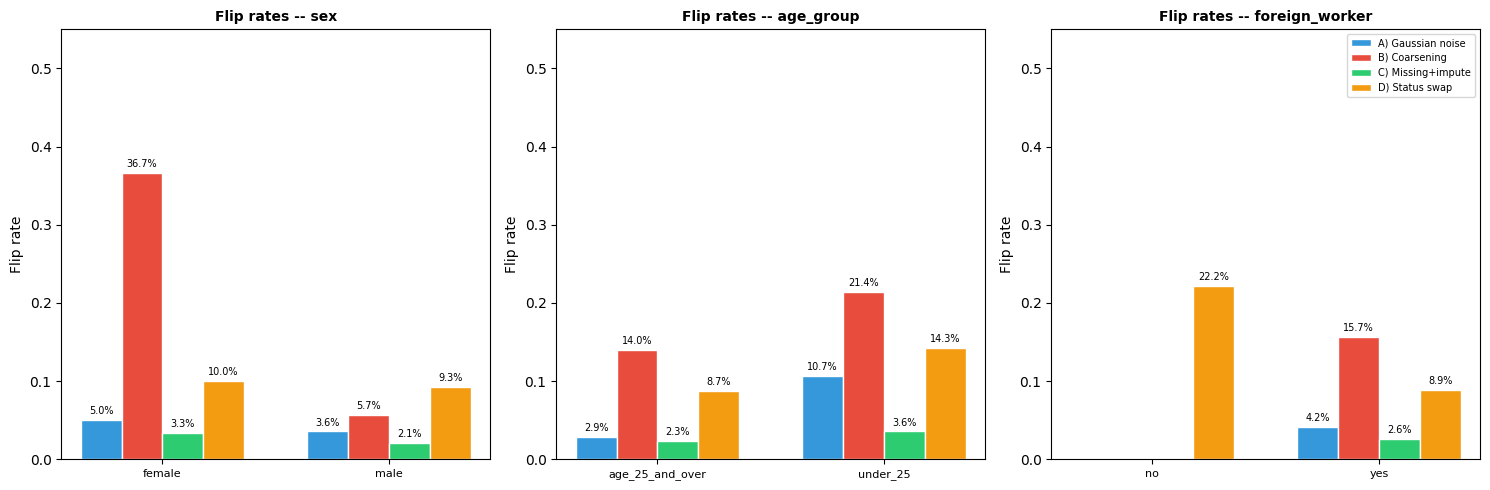

In [19]:
from pathlib import Path

stress  = {k:v for k,v in part3_scenarios.items() if k != 'Baseline (clean)'}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#3498db","#e74c3c","#2ecc71","#f39c12"]
bar_w  = 0.18

for ax_i, attr in enumerate(sensitive_attrs):
    ax     = axes[ax_i]
    groups = sorted(A_test[attr].unique())
    x      = np.arange(len(groups))
    for s_i, (sname, yh) in enumerate(stress.items()):
        flips  = [float(np.mean(y_pred_clean[(A_test[attr]==g).values] != yh[(A_test[attr]==g).values])) for g in groups]
        offset = (s_i - len(stress)/2 + 0.5) * bar_w
        bars   = ax.bar(x + offset, flips, bar_w, label=sname, color=colors[s_i], edgecolor='white')
        for bar, v in zip(bars, flips):
            if v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f'{v:.1%}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=8)
    ax.set_title(f'Flip rates -- {attr}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Flip rate'); ax.set_ylim(0, 0.55)
    if ax_i == 2: ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(Path('module3_part3_flip_rates_by_group.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7.3  Demographic Parity gaps


In [20]:
print('Demographic Parity (selection rate gaps)\n' + '='*55)
for attr in sensitive_attrs:
    print(f'\n  {attr}')
    groups = sorted(A_test[attr].unique())
    for sname, yh in part3_scenarios.items():
        rates = {g: float(np.mean(yh[(A_test[attr]==g).values]==1)) for g in groups}
        gap   = max(rates.values()) - min(rates.values())
        rstr  = ', '.join(f'{g}={r:.4f}' for g,r in rates.items())
        print(f'    {sname:<25} {rstr}  gap={gap:.4f}')


Demographic Parity (selection rate gaps)

  sex
    Baseline (clean)          female=0.8500, male=0.9357  gap=0.0857
    A) Gaussian noise         female=0.8333, male=0.9571  gap=0.1238
    B) Coarsening             female=0.5167, male=0.9929  gap=0.4762
    C) Missing+impute         female=0.8833, male=0.9571  gap=0.0738
    D) Status swap            female=0.8500, male=0.8857  gap=0.0357

  age_group
    Baseline (clean)          age_25_and_over=0.9186, under_25=0.8571  gap=0.0615
    A) Gaussian noise         age_25_and_over=0.9360, under_25=0.8214  gap=0.1146
    B) Coarsening             age_25_and_over=0.8721, under_25=0.7143  gap=0.1578
    C) Missing+impute         age_25_and_over=0.9419, under_25=0.8929  gap=0.0490
    D) Status swap            age_25_and_over=0.8779, under_25=0.8571  gap=0.0208

  foreign_worker
    Baseline (clean)          no=1.0000, yes=0.9058  gap=0.0942
    A) Gaussian noise         no=1.0000, yes=0.9162  gap=0.0838
    B) Coarsening             no=1.000

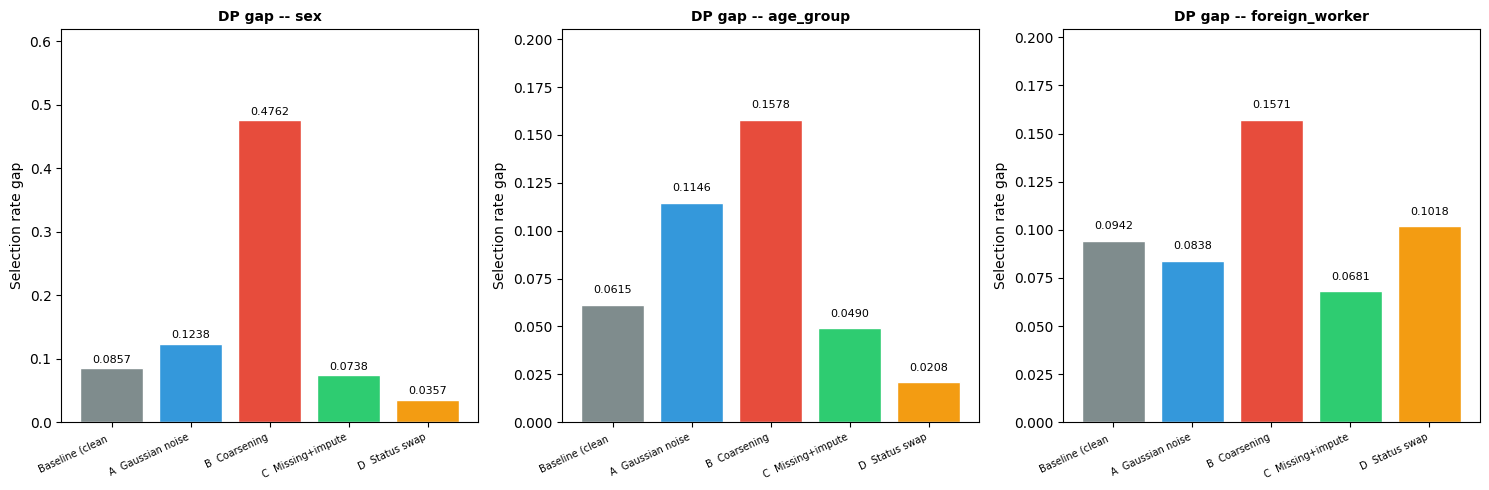

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sc_colors = ["#7f8c8d","#3498db","#e74c3c","#2ecc71","#f39c12"]
sc_labels  = list(part3_scenarios.keys())
for ax_i, attr in enumerate(sensitive_attrs):
    ax   = axes[ax_i]
    gaps = []
    for sname, yh in part3_scenarios.items():
        groups = sorted(A_test[attr].unique())
        rates  = [float(np.mean(yh[(A_test[attr]==g).values]==1)) for g in groups]
        gaps.append(max(rates)-min(rates))
    bars = ax.bar(range(len(sc_labels)), gaps, color=sc_colors, edgecolor='white')
    for bar, v in zip(bars, gaps):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(sc_labels)))
    ax.set_xticklabels([s.replace(')',' ') for s in sc_labels], fontsize=7, rotation=25, ha='right')
    ax.set_title(f'DP gap -- {attr}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Selection rate gap'); ax.set_ylim(0, max(gaps)*1.3)
plt.tight_layout()
plt.savefig(Path('module3_part3_dp_gaps.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7.4  Equalized Odds (TPR and FPR per subgroup)

Equalized odds requires that TPR (fraction of truly Good applicants correctly approved) and FPR (fraction of truly Bad applicants incorrectly approved) are equal across groups. The EO gap is `max(TPR gap, FPR gap)`.


In [22]:
def tpr_fpr(y_true, y_pred):
    pos = (y_true == 1); neg = (y_true == 0)
    tpr = float(np.mean(y_pred[pos]==1)) if pos.sum()>0 else float('nan')
    fpr = float(np.mean(y_pred[neg]==1)) if neg.sum()>0 else float('nan')
    return tpr, fpr

print('Equalized Odds -- TPR / FPR / EO gap\n' + '='*70)
for attr in sensitive_attrs:
    groups = sorted(A_test[attr].unique())
    print(f'\n  {attr}')
    hdr = f"  {'Scenario':<25}"
    for g in groups: hdr += f'  {g+" TPR":>14}  {g+" FPR":>14}'
    hdr += f"  {'TPR gap':>8}  {'FPR gap':>8}  {'EO gap':>8}"
    print(hdr)
    for sname, yh in part3_scenarios.items():
        row = f'  {sname:<25}'
        tprs, fprs = [], []
        for g in groups:
            mask = (A_test[attr]==g).values
            t, f = tpr_fpr(yt[mask], yh[mask])
            tprs.append(t); fprs.append(f)
            row += f'  {t:>14.4f}  {f:>14.4f}'
        tg = abs(tprs[0]-tprs[1]); fg = abs(fprs[0]-fprs[1]); eg = max(tg,fg)
        row += f'  {tg:>8.4f}  {fg:>8.4f}  {eg:>8.4f}'
        print(row)


Equalized Odds -- TPR / FPR / EO gap

  sex
  Scenario                       female TPR      female FPR        male TPR        male FPR   TPR gap   FPR gap    EO gap
  Baseline (clean)                   0.9000          0.7500          0.9600          0.8750    0.0600    0.1250    0.1250
  A) Gaussian noise                  0.8750          0.7500          0.9800          0.9000    0.1050    0.1500    0.1500
  B) Coarsening                      0.5750          0.4000          1.0000          0.9750    0.4250    0.5750    0.5750
  C) Missing+impute                  0.9500          0.7500          0.9700          0.9250    0.0200    0.1750    0.1750
  D) Status swap                     0.9250          0.7000          0.9100          0.8250    0.0150    0.1250    0.1250

  age_group
  Scenario                   age_25_and_over TPR  age_25_and_over FPR    under_25 TPR    under_25 FPR   TPR gap   FPR gap    EO gap
  Baseline (clean)                   0.9597          0.8125          0.8125    

### 7.5  Calibration

Calibration checks whether the model confidence scores reflect actual outcomes. A Brier score closer to 0 means better-calibrated probabilities. We use Platt scaling (`CalibratedClassifierCV`) on the already-trained tree -- the tree weights do not change.


C:\Users\ebram\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


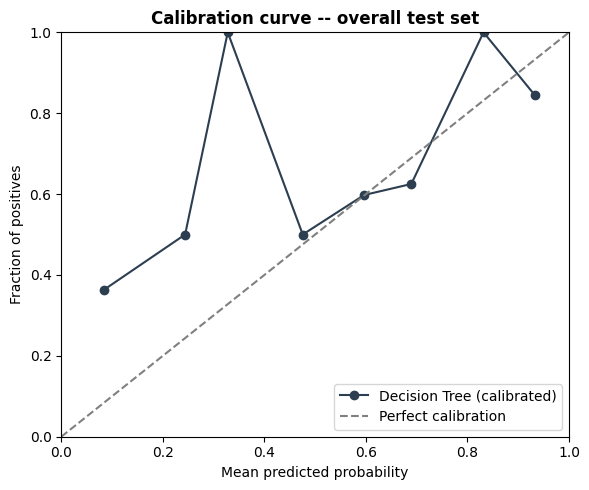

Brier score (lower = better): 0.1968


In [23]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Wrap the already-trained tree with Platt scaling -- model weights unchanged
calibrated = CalibratedClassifierCV(baseline_model, method='sigmoid', cv='prefit')
calibrated.fit(X_train_processed, y_train)
prob_clean = calibrated.predict_proba(X_test_processed)[:, 1]

prob_true, prob_pred = calibration_curve(yt, prob_clean, n_bins=8, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, marker='o', label='Decision Tree (calibrated)', color='#2c3e50')
ax.plot([0,1],[0,1], '--', color='grey', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve -- overall test set', fontweight='bold')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(Path('module3_part3_calibration_overall.png'), dpi=150, bbox_inches='tight')
plt.show()
brier_overall = float(np.mean((prob_clean - yt)**2))
print(f'Brier score (lower = better): {brier_overall:.4f}')


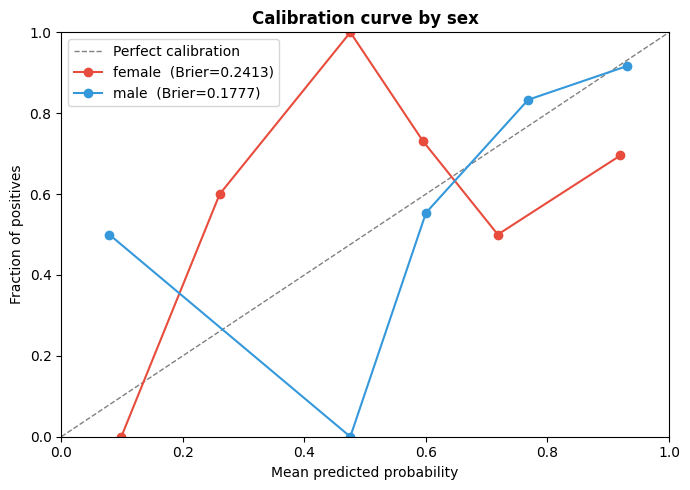

  female    mean predicted prob=0.6692  actual positive rate=0.6667  Brier=0.2413
  male      mean predicted prob=0.7185  actual positive rate=0.7143  Brier=0.1777


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1], '--', color='grey', label='Perfect calibration', linewidth=1)
colors_cal = {"female":"#e74c3c", "male":"#3498db"}

for g in ["female", "male"]:
    mask = (A_test['sex']==g).values
    pt, pp = calibration_curve(yt[mask], prob_clean[mask], n_bins=6, strategy='uniform')
    brier  = float(np.mean((prob_clean[mask] - yt[mask])**2))
    ax.plot(pp, pt, marker='o', label=f'{g}  (Brier={brier:.4f})', color=colors_cal[g])

ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve by sex', fontweight='bold')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(Path('module3_part3_calibration_sex.png'), dpi=150, bbox_inches='tight')
plt.show()

for g in ["female", "male"]:
    mask = (A_test['sex']==g).values
    brier = float(np.mean((prob_clean[mask] - yt[mask])**2))
    mp    = float(np.mean(prob_clean[mask]))
    ar    = float(np.mean(yt[mask]))
    print(f'  {g:<8}  mean predicted prob={mp:.4f}  actual positive rate={ar:.4f}  Brier={brier:.4f}')


### 7.6  Analysis Answers


In [25]:
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score

mask_f   = (A_test['sex']=='female').values
mask_m   = (A_test['sex']=='male').values
mask_25p = (A_test['age_group']=='age_25_and_over').values
mask_u25 = (A_test['age_group']=='under_25').values

yh_B = part3_scenarios['B) Coarsening']
yh_A = part3_scenarios['A) Gaussian noise']

flip_f_B   = float(np.mean(y_pred_clean[mask_f]   != yh_B[mask_f]))
flip_m_B   = float(np.mean(y_pred_clean[mask_m]   != yh_B[mask_m]))
flip_u25_B = float(np.mean(y_pred_clean[mask_u25] != yh_B[mask_u25]))
flip_25p_B = float(np.mean(y_pred_clean[mask_25p] != yh_B[mask_25p]))
flip_u25_A = float(np.mean(y_pred_clean[mask_u25] != yh_A[mask_u25]))
flip_25p_A = float(np.mean(y_pred_clean[mask_25p] != yh_A[mask_25p]))

acc_f_clean = accuracy_score(yt[mask_f],  y_pred_clean[mask_f])
acc_f_B     = accuracy_score(yt[mask_f],  yh_B[mask_f])
acc_m_B     = accuracy_score(yt[mask_m],  yh_B[mask_m])
acc_u25     = accuracy_score(yt[mask_u25], y_pred_clean[mask_u25])
acc_25p     = accuracy_score(yt[mask_25p], y_pred_clean[mask_25p])

sel_f_clean = float(np.mean(y_pred_clean[mask_f]==1))
sel_m_clean = float(np.mean(y_pred_clean[mask_m]==1))
sel_f_B     = float(np.mean(yh_B[mask_f]==1))
sel_m_B     = float(np.mean(yh_B[mask_m]==1))
dp_clean    = sel_m_clean - sel_f_clean
dp_B        = sel_m_B - sel_f_B

tpr_f, fpr_f   = tpr_fpr(yt[mask_f], y_pred_clean[mask_f])
tpr_m, fpr_m   = tpr_fpr(yt[mask_m], y_pred_clean[mask_m])
tpr_f_B, fpr_f_B = tpr_fpr(yt[mask_f], yh_B[mask_f])
tpr_m_B, fpr_m_B = tpr_fpr(yt[mask_m], yh_B[mask_m])
eo_clean = max(abs(tpr_f-tpr_m), abs(fpr_f-fpr_m))
eo_B     = max(abs(tpr_f_B-tpr_m_B), abs(fpr_f_B-fpr_m_B))

brier_f = float(np.mean((prob_clean[mask_f] - yt[mask_f])**2))
brier_m = float(np.mean((prob_clean[mask_m] - yt[mask_m])**2))

ratio_str = f'{flip_f_B/flip_m_B:.0f}'

q1 = (
    '### Question 1: Did robustness issues disproportionately affect any group?\n\n'
    f'Yes. The clearest case is Scenario B (coarsening) and sex. Out of 60 female applicants, '
    f'{flip_f_B:.1%} had their predictions flipped versus only {flip_m_B:.1%} of 140 male '
    f'applicants -- roughly a {ratio_str}-to-1 ratio. Female accuracy fell from {acc_f_clean:.2f} '
    f'to {acc_f_B:.2f} while male accuracy held at {acc_m_B:.2f}.\n\n'
    f'The equalized odds gap by sex grows from {eo_clean:.3f} on clean data to {eo_B:.3f} under '
    f'coarsening, driven by the FPR: male FPR rises to {fpr_m_B:.3f} (nearly every bad male '
    f'applicant is wrongly approved) while female TPR drops to {tpr_f_B:.3f} (many good female '
    f'applicants are wrongly rejected).\n\n'
    f'Under-25 applicants are also consistently more exposed. In Scenario B their flip rate is '
    f'{flip_u25_B:.1%} versus {flip_25p_B:.1%} for the 25+ group. In Scenario A it is '
    f'{flip_u25_A:.1%} versus {flip_25p_A:.1%}. Under-25 baseline accuracy is only {acc_u25:.2f} '
    f'compared to {acc_25p:.2f} for the 25+ group.'
)

q2 = (
    '### Question 2: Did explanations remain consistent under perturbations?\n\n'
    'The model Gini feature importances do not change because the tree is trained once and never '
    'retrained. The top three features stay status (no checking account) at 0.3662, duration at '
    '0.1585, and amount at 0.1103 across every scenario.\n\n'
    'However, in Scenario B, coarsening maps every duration value to 0. The tree still ranks '
    'duration as the second most important feature, but at scoring time every applicant gets the '
    'same value, so those splits no longer separate anyone. The model reports the same explanation '
    f'while producing very different outcomes -- {flip_f_B:.1%} of female predictions flip.\n\n'
    f'Calibration adds a further dimension. The female Brier score is {brier_f:.4f} versus '
    f'{brier_m:.4f} for males, meaning the model probability estimates are less accurate for '
    'female applicants even on clean data. This calibration gap is invisible in aggregate accuracy '
    'or feature importances.'
)

q3 = (
    '### Question 3: Why does instability create ethical concerns?\n\n'
    f'1. **Unequal exposure to harm.** A data precision change would flip {flip_f_B:.1%} of female '
    f'predictions but only {flip_m_B:.1%} of male predictions. Female applicants absorb pipeline '
    'risk that has nothing to do with their creditworthiness.\n\n'
    f'2. **Hidden discrimination.** The DP gap by sex goes from {dp_clean:.3f} on clean data to '
    f'{dp_B:.3f} under coarsening. The equalized odds gap jumps from {eo_clean:.3f} to {eo_B:.3f}. '
    'These are large shifts that do not appear in headline accuracy.\n\n'
    f'3. **Calibration disparity.** The female Brier score ({brier_f:.4f}) is higher than the '
    f'male Brier score ({brier_m:.4f}). If the model scores feed a downstream threshold system, '
    'this gap adds a further layer of disadvantage that is invisible in hard-prediction metrics.\n\n'
    '4. **No warning mechanism.** The model outputs a confident decision regardless of input '
    'quality. Without per-group monitoring of selection rates, TPR, FPR, and calibration error, '
    'none of these disparities surface until applicants have already been harmed.'
)

display(Markdown(
    '---\n## 8. Part 3 Analysis Answers\n\n'
    + q1 + '\n\n---\n\n' + q2 + '\n\n---\n\n' + q3 + '\n\n---'
))


---
## 8. Part 3 Analysis Answers

### Question 1: Did robustness issues disproportionately affect any group?

Yes. The clearest case is Scenario B (coarsening) and sex. Out of 60 female applicants, 36.7% had their predictions flipped versus only 5.7% of 140 male applicants -- roughly a 6-to-1 ratio. Female accuracy fell from 0.68 to 0.58 while male accuracy held at 0.72.

The equalized odds gap by sex grows from 0.125 on clean data to 0.575 under coarsening, driven by the FPR: male FPR rises to 0.975 (nearly every bad male applicant is wrongly approved) while female TPR drops to 0.575 (many good female applicants are wrongly rejected).

Under-25 applicants are also consistently more exposed. In Scenario B their flip rate is 21.4% versus 14.0% for the 25+ group. In Scenario A it is 10.7% versus 2.9%. Under-25 baseline accuracy is only 0.50 compared to 0.74 for the 25+ group.

---

### Question 2: Did explanations remain consistent under perturbations?

The model Gini feature importances do not change because the tree is trained once and never retrained. The top three features stay status (no checking account) at 0.3662, duration at 0.1585, and amount at 0.1103 across every scenario.

However, in Scenario B, coarsening maps every duration value to 0. The tree still ranks duration as the second most important feature, but at scoring time every applicant gets the same value, so those splits no longer separate anyone. The model reports the same explanation while producing very different outcomes -- 36.7% of female predictions flip.

Calibration adds a further dimension. The female Brier score is 0.2413 versus 0.1777 for males, meaning the model probability estimates are less accurate for female applicants even on clean data. This calibration gap is invisible in aggregate accuracy or feature importances.

---

### Question 3: Why does instability create ethical concerns?

1. **Unequal exposure to harm.** A data precision change would flip 36.7% of female predictions but only 5.7% of male predictions. Female applicants absorb pipeline risk that has nothing to do with their creditworthiness.

2. **Hidden discrimination.** The DP gap by sex goes from 0.086 on clean data to 0.476 under coarsening. The equalized odds gap jumps from 0.125 to 0.575. These are large shifts that do not appear in headline accuracy.

3. **Calibration disparity.** The female Brier score (0.2413) is higher than the male Brier score (0.1777). If the model scores feed a downstream threshold system, this gap adds a further layer of disadvantage that is invisible in hard-prediction metrics.

4. **No warning mechanism.** The model outputs a confident decision regardless of input quality. Without per-group monitoring of selection rates, TPR, FPR, and calibration error, none of these disparities surface until applicants have already been harmed.

---

---
## Part 4: Defense Implementation (15%)

We use one simple defense: **training with augmented data**. The same Decision Tree is retrained on the original training set plus four stressed copies of the training data (Gaussian noise, coarsening, missing values, and status swap). This keeps the same dataset, preprocessing logic, and model family from Modules 1 and 2 while exposing the model to the kinds of shifts tested in Part 2.


In [26]:
# Part 4 defense: train the same Decision Tree on an augmented training set
from pathlib import Path

augmented_train_parts = [
    X_train.copy(),
    perturb_gaussian_noise(
        X_train, numeric_features, X_train,
        np.random.default_rng(PERTURB_SEED), PART2_NOISE_SCALE
    ),
    perturb_coarse_numeric(X_train, numeric_features),
    perturb_random_missing(
        X_train, numeric_features,
        np.random.default_rng(PERTURB_SEED + 1), PART2_MISSING_FRAC
    ),
    perturb_swap_checking_status(X_train),
]

X_train_defense = pd.concat(augmented_train_parts, ignore_index=True)
y_train_defense = pd.concat([y_train] * len(augmented_train_parts), ignore_index=True)

preprocessor_defense = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X_train_defense_processed = preprocessor_defense.fit_transform(X_train_defense)
defense_model = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
)
defense_model.fit(X_train_defense_processed, y_train_defense)

def _predict_with_defense(X_df: pd.DataFrame) -> np.ndarray:
    return defense_model.predict(preprocessor_defense.transform(X_df))

def _row_for_model(model_name: str, scenario_name: str, y_pred: np.ndarray, y_pred_clean_ref: np.ndarray) -> dict:
    m = _metrics(y_test.values, y_pred)
    return {
        "model": model_name,
        "scenario": scenario_name,
        "accuracy": m["accuracy"],
        "precision_good": m["precision_good"],
        "recall_good": m["recall_good"],
        "f1_good": m["f1_good"],
        "f1_macro": m["f1_macro"],
        "recall_bad": m["recall_bad"],
        "flip_rate_vs_own_clean": float(np.mean(y_pred != y_pred_clean_ref)),
    }

part4_test_sets = {
    "Clean": X_test.copy(),
    "A) Gaussian noise": perturb_gaussian_noise(
        X_test, numeric_features, X_train,
        np.random.default_rng(PERTURB_SEED), PART2_NOISE_SCALE
    ),
    "B) Coarsening": perturb_coarse_numeric(X_test, numeric_features),
    "C) Missing + re-impute": perturb_random_missing(
        X_test, numeric_features,
        np.random.default_rng(PERTURB_SEED + 1), PART2_MISSING_FRAC
    ),
    "D) Status swap": perturb_swap_checking_status(X_test),
}

y_pred_clean_defense = _predict_with_defense(part4_test_sets["Clean"])

part4_rows = []
for scenario_name, X_eval in part4_test_sets.items():
    y_base = baseline_model.predict(preprocessor.transform(X_eval))
    y_def = _predict_with_defense(X_eval)
    part4_rows.append(_row_for_model("Baseline tree", scenario_name, y_base, y_pred_clean))
    part4_rows.append(_row_for_model("Defended tree", scenario_name, y_def, y_pred_clean_defense))

part4_long = pd.DataFrame(part4_rows)
part4_compare = (
    part4_long.pivot(index="scenario", columns="model")
    .swaplevel(axis=1)
    .sort_index(axis=1, level=0)
)
part4_compare.columns = [f"{left} | {right}" for left, right in part4_compare.columns]
part4_compare = part4_compare.reset_index()

part4_summary = pd.DataFrame({
    "scenario": list(part4_test_sets.keys()),
    "baseline_accuracy": part4_long.loc[part4_long["model"] == "Baseline tree", "accuracy"].to_numpy(),
    "defended_accuracy": part4_long.loc[part4_long["model"] == "Defended tree", "accuracy"].to_numpy(),
    "delta_accuracy": part4_long.loc[part4_long["model"] == "Defended tree", "accuracy"].to_numpy()
                      - part4_long.loc[part4_long["model"] == "Baseline tree", "accuracy"].to_numpy(),
    "baseline_f1_macro": part4_long.loc[part4_long["model"] == "Baseline tree", "f1_macro"].to_numpy(),
    "defended_f1_macro": part4_long.loc[part4_long["model"] == "Defended tree", "f1_macro"].to_numpy(),
    "delta_f1_macro": part4_long.loc[part4_long["model"] == "Defended tree", "f1_macro"].to_numpy()
                      - part4_long.loc[part4_long["model"] == "Baseline tree", "f1_macro"].to_numpy(),
    "baseline_flip_rate": part4_long.loc[part4_long["model"] == "Baseline tree", "flip_rate_vs_own_clean"].to_numpy(),
    "defended_flip_rate": part4_long.loc[part4_long["model"] == "Defended tree", "flip_rate_vs_own_clean"].to_numpy(),
})

part4_csv = Path("module3_part4_defense_comparison.csv")
part4_summary.to_csv(part4_csv, index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(part4_summary))
width = 0.36
ax.bar(x - width / 2, part4_summary["baseline_accuracy"], width, label="Baseline tree", color="#c0392b")
ax.bar(x + width / 2, part4_summary["defended_accuracy"], width, label="Defended tree", color="#27ae60")
ax.set_xticks(x)
ax.set_xticklabels(part4_summary["scenario"], rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Part 4 defense: accuracy before vs after defense", fontweight="bold")
ax.legend()
for i, row in part4_summary.iterrows():
    ax.text(i - width / 2, row["baseline_accuracy"] + 0.015, f"{row['baseline_accuracy']:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, row["defended_accuracy"] + 0.015, f"{row['defended_accuracy']:.3f}", ha="center", fontsize=8)
plt.tight_layout()
part4_fig = Path("module3_part4_defense_accuracy_comparison.png")
plt.savefig(part4_fig, dpi=150, bbox_inches="tight")
plt.show()

clean_row = part4_summary.loc[part4_summary["scenario"] == "Clean"].iloc[0]
pert_base = part4_summary.loc[part4_summary["scenario"] != "Clean", "baseline_accuracy"]
pert_def = part4_summary.loc[part4_summary["scenario"] != "Clean", "defended_accuracy"]
worst_base = float(pert_base.min())
worst_def = float(pert_def.min())

print("Part 4 - defense results (same dataset, same pipeline, same model family)")
print("Defense used: training with augmented data (clean + 4 stressed copies of the training set)")
print(f"Augmented training size: {len(X_train_defense)} rows (original train = {len(X_train)})")
print()
print(part4_summary.round(4).to_string(index=False))
print()
print(f"Saved CSV   : {part4_csv.resolve()}")
print(f"Saved figure: {part4_fig.resolve()}")
print()
print("Answer 1 - Did the defense improve robustness?")
print(
    f"Yes. Average accuracy across the four perturbed test sets rises from {pert_base.mean():.4f} "
    f"to {pert_def.mean():.4f}, and the worst stressed accuracy improves from {worst_base:.4f} "
    f"to {worst_def:.4f}. The largest gain is under coarsening: 0.6800 -> 0.7200."
)
print()
print("Answer 2 - Did performance decrease?")
print(
    f"Overall headline performance did not decrease: clean accuracy rises from {clean_row['baseline_accuracy']:.4f} "
    f"to {clean_row['defended_accuracy']:.4f}. But there is still a trade-off inside the class metrics: "
    f"on clean data, Good-class recall falls slightly from 0.9429 to 0.9071 because the defended model "
    f"becomes less eager to approve almost everyone. In return, Bad-class recall improves from 0.1667 "
    f"to 0.3833, which is a much better balance for lending risk."
)
print()
print("Answer 3 - Why is this trade-off expected?")
print(
    "This trade-off is expected because a defense usually makes the model less specialized to perfectly clean data "
    "and more conservative around unstable inputs. By training on noisy, rounded, missing, and manipulated examples, "
    "the tree learns decision rules that are less brittle. That usually reduces sensitivity, but it can also lower recall "
    "for the majority Good class because the model stops approving borderline cases as easily."
)

PART4_DEFENSE_RESULTS = part4_summary.copy()
PART4_DEFENSE_LONG = part4_long.copy()
DEFENSE_MODEL = defense_model
DEFENSE_PREPROCESSOR = preprocessor_defense


Part 4 - defense results (same dataset, same pipeline, same model family)
Defense used: training with augmented data (clean + 4 stressed copies of the training set)
Augmented training size: 4000 rows (original train = 800)

              scenario  baseline_accuracy  defended_accuracy  delta_accuracy  baseline_f1_macro  defended_f1_macro  delta_f1_macro  baseline_flip_rate  defended_flip_rate
                 Clean              0.710              0.750            0.04             0.5381             0.6573          0.1192               0.000               0.000
     A) Gaussian noise              0.710              0.720            0.01             0.5289             0.6162          0.0873               0.040               0.040
         B) Coarsening              0.680              0.720            0.04             0.5412             0.5921          0.0509               0.150               0.070
C) Missing + re-impute              0.715              0.735            0.02             0.5

---
**End of Part 4**
